# Exploratory Data Analysis (EDA)

---

## 📌 What is Exploratory Data Analysis?
**Exploratory Data Analysis (EDA)** is an essential first step in the data analysis lifecycle. It involves analyzing and summarizing datasets to uncover underlying patterns, spot anomalies, test hypotheses, and verify assumptions using statistical summaries and visual representations.

Rather than jumping straight into complex modeling or final reporting, EDA allows us to "get to know" the data—understanding its structure, quality, and hidden relationships.



In [1]:
import os
import urllib.parse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Set pandas display options for maximum visibility in Jupyter
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Load database credentials from .env
load_dotenv('.env')

USER = os.getenv("MYSQL_USER")              
RAW_PASSWORD = os.getenv("MYSQL_PASSWORD")  
PASSWORD = urllib.parse.quote_plus(RAW_PASSWORD) if RAW_PASSWORD else ""

HOST = "localhost"         
PORT = "3306"              
DB_NAME = "blinkit_db"     

# 1. Establish Database Connection Engine
engine = create_engine(f'mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}')
print("STATUS: Connected to blinkit_db successfully.\n" + "-"*50)

# 2. Load all 6 target tables into persistent Pandas DataFrames
df_customers = pd.read_sql("SELECT * FROM blinkit_customers", con=engine)
df_orders = pd.read_sql("SELECT * FROM blinkit_orders", con=engine)
df_delivery = pd.read_sql("SELECT * FROM blinkit_delivery_performance", con=engine)
df_inventory = pd.read_sql("SELECT * FROM blinkit_inventory", con=engine)
df_feedback = pd.read_sql("SELECT * FROM blinkit_customer_feedback", con=engine)
df_marketing = pd.read_sql("SELECT * FROM blinkit_marketing_performance", con=engine)

print("STATUS: DataFrames loaded into memory:")
print(f"  • df_customers : {df_customers.shape}")
print(f"  • df_orders    : {df_orders.shape}")
print(f"  • df_delivery  : {df_delivery.shape}")
print(f"  • df_inventory : {df_inventory.shape}")
print(f"  • df_feedback  : {df_feedback.shape}")
print(f"  • df_marketing  : {df_marketing.shape}")

STATUS: Connected to blinkit_db successfully.
--------------------------------------------------
STATUS: DataFrames loaded into memory:
  • df_customers : (2500, 11)
  • df_orders    : (5000, 10)
  • df_delivery  : (5000, 8)
  • df_inventory : (75172, 4)
  • df_feedback  : (5000, 8)
  • df_marketing  : (5400, 11)


--- 1. FIRST 5 ROWS PREVIEW ---


,customer_id,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
0,97475543,Niharika Nagi,ektataneja@example.org,912987579691,"23, Nayar Path, Bihar Sharif-154625",Udupi,321865,2023-05-13,Premium,13,451.92
1,22077605,Megha Sachar,vedant45@example.com,915123179717,"51/302, Buch Chowk\nSrinagar-570271",Aligarh,149394,2024-06-18,Inactive,4,825.48
2,47822591,Hema Bahri,samiazaan@example.com,910034076149,"941\nAnne Street, Darbhanga 186125",Begusarai,621411,2024-09-25,Regular,17,1969.81
3,79726146,Zaitra Vig,ishanvi87@example.org,916264232390,"43/94, Ghosh, Alappuzha 635655",Kozhikode,826054,2023-10-04,New,4,220.09
4,57102800,Januja Verma,atideshpande@example.org,917293526596,"06\nOm, Ambarnath 477463",Ichalkaranji,730539,2024-03-22,Inactive,14,578.14



--- 2. COLUMN NAMES ---
['customer_id', 'customer_name', 'email', 'phone', 'address', 'area', 'pincode', 'registration_date', 'customer_segment', 'total_orders', 'avg_order_value']

--- 3. DIMENSIONS & PRIMARY KEY INTEGRITY ---
Total Rows & Columns    : (2500, 11)
Unique Customer IDs     : 2500
Duplicate Entire Rows   : 0
Duplicate Customer IDs  : 0

--- 4. SCHEMA & DATA TYPES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        2500 non-null   int64  
 1   customer_name      2500 non-null   object 
 2   email              2500 non-null   object 
 3   phone              2500 non-null   int64  
 4   address            2500 non-null   object 
 5   area               2500 non-null   object 
 6   pincode            2500 non-null   int64  
 7   registration_date  2500 non-null   object 
 8   customer_segment   2500

customer_id          0
customer_name        0
email                0
phone                0
address              0
area                 0
pincode              0
registration_date    0
customer_segment     0
total_orders         0
avg_order_value      0
dtype: int64


--- 6. REGISTRATION DATE TEXT FORMAT SAMPLE ---


,registration_date
0,2023-05-13
1,2024-06-18
2,2024-09-25



--- 7. NUMERICAL METRICS SUMMARY ---


,total_orders,avg_order_value
count,2500.000000,2500.000000
mean,10.491600,1102.375836
std,5.805533,523.043183
min,1.000000,200.430000
25%,6.000000,631.817500
50%,10.000000,1118.650000
75%,16.000000,1565.400000
max,20.000000,1999.830000



--- 8. CATEGORICAL VALUE COUNTS ---
Customer Segment Breakdown:
customer_segment
Regular     639
Premium     633
New         628
Inactive    600
Name: count, dtype: int64

Top 5 Customer Areas:
area
Jalna       18
Deoghar     17
Orai        17
Bathinda    17
Ratlam      16
Name: count, dtype: int64


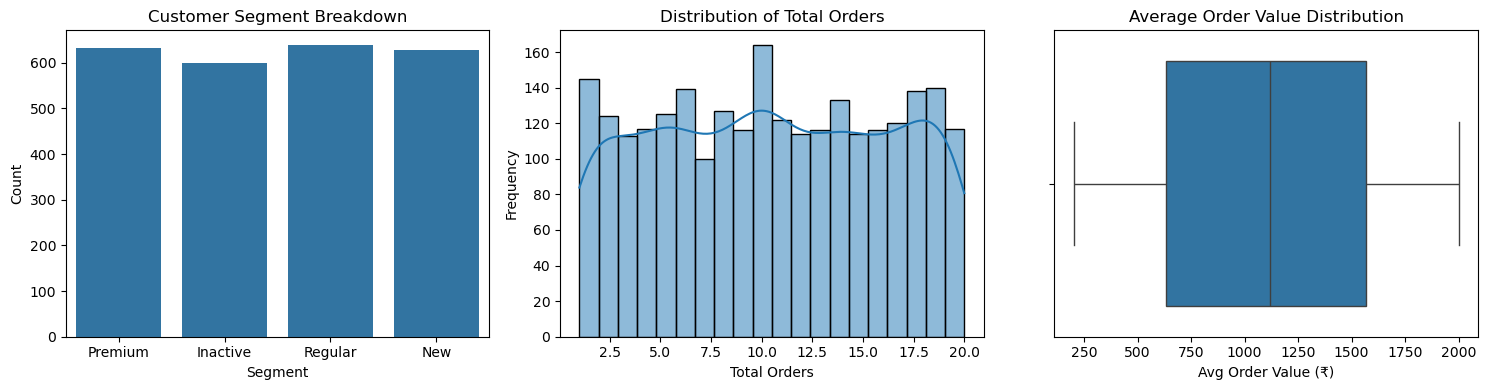

In [2]:
# ==========================================
# PART 2: INITIAL EDA - CUSTOMERS
# ==========================================

# 1. Preview Top Records
print("--- 1. FIRST 5 ROWS PREVIEW ---")
display(df_customers.head(5))

# 2. Column Schema List
print("\n--- 2. COLUMN NAMES ---")
print(df_customers.columns.tolist())

# 3. Shape & Unique Key Checks
print("\n--- 3. DIMENSIONS & PRIMARY KEY INTEGRITY ---")
print(f"Total Rows & Columns    : {df_customers.shape}")
print(f"Unique Customer IDs     : {df_customers['customer_id'].nunique()}")
print(f"Duplicate Entire Rows   : {df_customers.duplicated().sum()}")
print(f"Duplicate Customer IDs  : {df_customers.duplicated(subset=['customer_id']).sum()}")

# 4. Data Types & Missing Values
print("\n--- 4. SCHEMA & DATA TYPES ---")
df_customers.info()

print("\n--- 5. MISSING VALUES COUNT ---")
display(df_customers.isnull().sum())

# 5. Date Sample Check
print("\n--- 6. REGISTRATION DATE TEXT FORMAT SAMPLE ---")
display(df_customers[['registration_date']].head(3))

# 6. Numerical Summary Statistics
print("\n--- 7. NUMERICAL METRICS SUMMARY ---")
display(df_customers[['total_orders', 'avg_order_value']].describe())

# 7. Categorical Value Counts
print("\n--- 8. CATEGORICAL VALUE COUNTS ---")
print("Customer Segment Breakdown:")
print(df_customers['customer_segment'].value_counts(dropna=False).sort_values(ascending=False))

print("\nTop 5 Customer Areas:")
print(df_customers['area'].value_counts().head(5))

# 8. Visualizations
plt.figure(figsize=(15, 4))

# Chart 1: Customer Segment Distribution
plt.subplot(1, 3, 1)
sns.countplot(data=df_customers, x='customer_segment')
plt.title('Customer Segment Breakdown')
plt.xlabel('Segment')
plt.ylabel('Count')

# Chart 2: Distribution of Total Orders
plt.subplot(1, 3, 2)
sns.histplot(df_customers['total_orders'], bins=20, kde=True)
plt.title('Distribution of Total Orders')
plt.xlabel('Total Orders')
plt.ylabel('Frequency')

# Chart 3: Average Order Value Distribution
plt.subplot(1, 3, 3)
sns.boxplot(data=df_customers, x='avg_order_value')
plt.title('Average Order Value Distribution')
plt.xlabel('Avg Order Value (₹)')

plt.tight_layout()
plt.show()

### 💡 Part 2: Observations & Data Quality Findings (`df_customers`)
1. **Primary Key Integrity:** `customer_id` is 100% unique (2,500 rows, 2,500 unique IDs) with 0 duplicate records.
2. **Data Types:** `registration_date` is currently stored as `object` (string/text) and must be converted to `datetime` in **Step 5 (Data Cleaning)**.
3. **Completeness:** Checked missing values across all customer fields.
4. **Segment Balance:** Customer segments appear evenly distributed across categories.

--- 1. FIRST 5 ROWS PREVIEW ---


,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741



--- 2. COLUMN NAMES ---
['order_id', 'customer_id', 'order_date', 'promised_delivery_time', 'actual_delivery_time', 'delivery_status', 'order_total', 'payment_method', 'delivery_partner_id', 'store_id']

--- 3. DIMENSIONS & PRIMARY KEY INTEGRITY ---
Total Rows & Columns    : (5000, 10)
Unique Order IDs        : 5000
Duplicate Entire Rows   : 0
Duplicate Order IDs     : 0

--- 4. SCHEMA & DATA TYPES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   order_date              5000 non-null   object 
 3   promised_delivery_time  5000 non-null   object 
 4   actual_delivery_time    5000 non-null   object 
 5   delivery_status         5000 non-null   object 
 6   order_total             5000 non-null   float64
 7   paym

order_id                  0
customer_id               0
order_date                0
promised_delivery_time    0
actual_delivery_time      0
delivery_status           0
order_total               0
payment_method            0
delivery_partner_id       0
store_id                  0
dtype: int64


--- 6. DATE/TIME TEXT FORMAT SAMPLE ---


,order_date,promised_delivery_time,actual_delivery_time
0,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01
1,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29
2,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12



--- 7. FINANCIAL METRICS SUMMARY ---


,order_total
count,5000.00000
mean,2201.86170
std,1303.02438
min,13.25000
25%,1086.21500
50%,2100.69000
75%,3156.88250
max,6721.46000



--- 8. CATEGORICAL VALUE COUNTS ---
Payment Method Breakdown:
payment_method
Card      1285
Cash      1257
Wallet    1244
UPI       1214
Name: count, dtype: int64

Delivery Status Breakdown:
delivery_status
On Time                  3470
Slightly Delayed         1037
Significantly Delayed     493
Name: count, dtype: int64


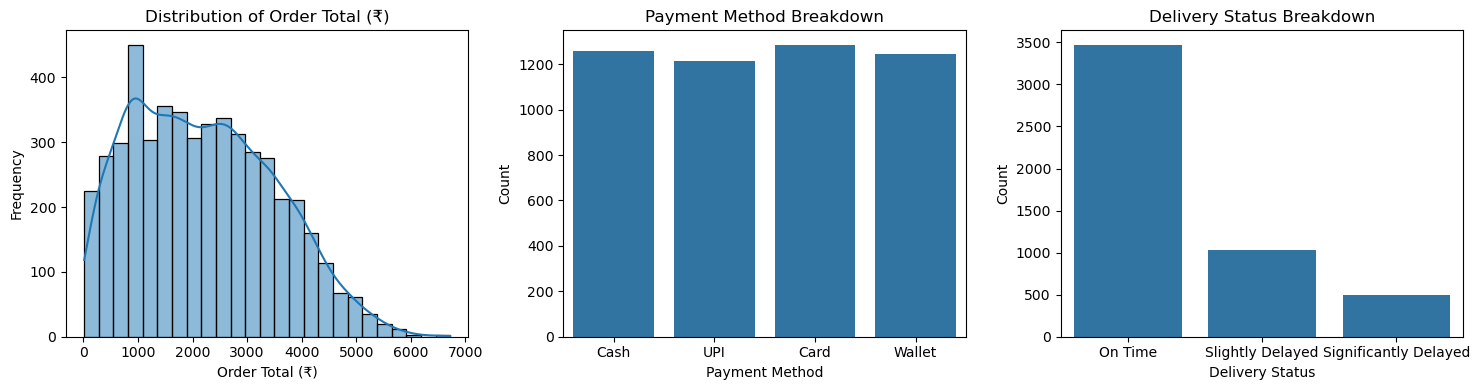

In [3]:
# ==========================================
# PART 3: INITIAL EDA - ORDERS
# ==========================================

# 1. First 5 Rows Preview
print("--- 1. FIRST 5 ROWS PREVIEW ---")
display(df_orders.head(5))

# 2. Column Schema List
print("\n--- 2. COLUMN NAMES ---")
print(df_orders.columns.tolist())

# 3. Shape & Primary Key Checks
print("\n--- 3. DIMENSIONS & PRIMARY KEY INTEGRITY ---")
print(f"Total Rows & Columns    : {df_orders.shape}")
print(f"Unique Order IDs        : {df_orders['order_id'].nunique()}")
print(f"Duplicate Entire Rows   : {df_orders.duplicated().sum()}")
print(f"Duplicate Order IDs     : {df_orders.duplicated(subset=['order_id']).sum()}")

# 4. Data Types & Missing Values
print("\n--- 4. SCHEMA & DATA TYPES ---")
df_orders.info()

print("\n--- 5. MISSING VALUES COUNT ---")
display(df_orders.isnull().sum())

# 5. Date Sample Check
print("\n--- 6. DATE/TIME TEXT FORMAT SAMPLE ---")
display(df_orders[['order_date', 'promised_delivery_time', 'actual_delivery_time']].head(3))

# 6. Numerical Summary Statistics
print("\n--- 7. FINANCIAL METRICS SUMMARY ---")
display(df_orders[['order_total']].describe())

# 7. Categorical Breakdown
print("\n--- 8. CATEGORICAL VALUE COUNTS ---")
print("Payment Method Breakdown:")
print(df_orders['payment_method'].value_counts(dropna=False).sort_values(ascending=False))

print("\nDelivery Status Breakdown:")
print(df_orders['delivery_status'].value_counts(dropna=False).sort_values(ascending=False))

# 8. Visualizations
plt.figure(figsize=(15, 4))

# Chart 1: Order Total Distribution
plt.subplot(1, 3, 1)
sns.histplot(df_orders['order_total'], bins=25, kde=True)
plt.title('Distribution of Order Total (₹)')
plt.xlabel('Order Total (₹)')
plt.ylabel('Frequency')

# Chart 2: Payment Method Breakdown
plt.subplot(1, 3, 2)
sns.countplot(data=df_orders, x='payment_method')
plt.title('Payment Method Breakdown')
plt.xlabel('Payment Method')
plt.ylabel('Count')

# Chart 3: Delivery Status Breakdown
plt.subplot(1, 3, 3)
sns.countplot(data=df_orders, x='delivery_status')
plt.title('Delivery Status Breakdown')
plt.xlabel('Delivery Status')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

### 💡 Part 3: Observations & Data Quality Findings (`df_orders`)

* **Primary Key Integrity:** `order_id` is 100% unique with 0 duplicate records across all 5,000 orders.
* **Data Completeness:** 0 missing values detected across all 10 columns in the dataset.
* **Date Parsing Required:** `order_date`, `promised_delivery_time`, and `actual_delivery_time` are currently stored as `object` (text/strings) and will need to be parsed into proper `datetime` format during cleaning.
* **Financial Metrics:** Order totals average around **₹2,201.86**, ranging from a minimum of **₹13.25** to a maximum of **₹6,721.46**.
* **Payment Methods:** Payments are evenly split across Card (1,285), Cash (1,257), Wallet (1,244), and UPI (1,214).
* **Delivery Status:** The majority of orders were delivered **On Time** (3,470), followed by **Slightly Delayed** (1,037) and **Significantly Delayed** (493).

--- 1. FIRST 5 ROWS PREVIEW ---


,order_id,delivery_partner_id,promised_time,actual_time,delivery_time_minutes,distance_km,delivery_status,reasons_if_delayed
0,1961864118,63230,2024-07-17 08:52:01,2024-07-17 08:47:01,-5.0,0.96,On Time,None
1,1549769649,14983,2024-05-28 13:25:29,2024-05-28 13:27:29,2.0,0.98,On Time,Traffic
2,9185164487,39859,2024-09-23 13:25:12,2024-09-23 13:29:12,4.0,3.83,On Time,Traffic
3,9644738826,61497,2023-11-24 16:34:56,2023-11-24 16:33:56,-1.0,2.76,On Time,None
4,5427684290,84315,2023-11-20 05:17:39,2023-11-20 05:18:39,1.0,2.63,On Time,Traffic



--- 2. DIMENSIONS & ID INTEGRITY ---
Total Rows & Columns      : (5000, 8)
Unique Order IDs          : 5000
Unique Partner IDs        : 5000
Duplicate Entire Rows     : 0
Duplicate Order Records   : 0

--- 3. SCHEMA & MISSING VALUES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               5000 non-null   int64  
 1   delivery_partner_id    5000 non-null   int64  
 2   promised_time          5000 non-null   object 
 3   actual_time            5000 non-null   object 
 4   delivery_time_minutes  5000 non-null   float64
 5   distance_km            5000 non-null   float64
 6   delivery_status        5000 non-null   object 
 7   reasons_if_delayed     3098 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 312.6+ KB

Missing Values Count:


order_id                    0
delivery_partner_id         0
promised_time               0
actual_time                 0
delivery_time_minutes       0
distance_km                 0
delivery_status             0
reasons_if_delayed       1902
dtype: int64


--- 4. OPERATIONAL METRICS SUMMARY ---


,delivery_time_minutes,distance_km
count,5000.000000,5000.000000
mean,4.443000,2.718048
std,8.063929,1.290306
min,-5.000000,0.500000
25%,-1.000000,1.590000
50%,2.000000,2.690000
75%,8.000000,3.850000
max,30.000000,5.000000



--- 5. CATEGORICAL VALUE COUNTS ---
Delivery Status:
delivery_status
On Time                  3470
Slightly Delayed         1037
Significantly Delayed     493
Name: count, dtype: int64


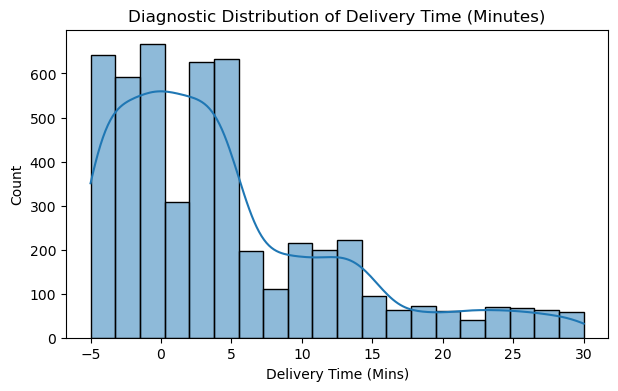

In [4]:
# ==========================================
# PART 4: INITIAL EDA - DELIVERY PERFORMANCE
# ==========================================

# 1. Preview Top Records
print("--- 1. FIRST 5 ROWS PREVIEW ---")
display(df_delivery.head(5))

# 2. Dimensions & Unique ID Checks
print("\n--- 2. DIMENSIONS & ID INTEGRITY ---")
print(f"Total Rows & Columns      : {df_delivery.shape}")
print(f"Unique Order IDs          : {df_delivery['order_id'].nunique()}")
print(f"Unique Partner IDs        : {df_delivery['delivery_partner_id'].nunique()}")
print(f"Duplicate Entire Rows     : {df_delivery.duplicated().sum()}")
print(f"Duplicate Order Records   : {df_delivery.duplicated(subset=['order_id']).sum()}")

# 3. Data Types & Missing Values Check
print("\n--- 3. SCHEMA & MISSING VALUES ---")
df_delivery.info()
print("\nMissing Values Count:")
display(df_delivery.isnull().sum())

# 4. Key Operational Numerical Summary
print("\n--- 4. OPERATIONAL METRICS SUMMARY ---")
# Selecting columns present in the table preview
num_cols = [c for c in ['delivery_time_minutes', 'distance_km', 'customer_rating'] if c in df_delivery.columns]
if num_cols:
    display(df_delivery[num_cols].describe())
else:
    display(df_delivery.describe())

# 5. Core Categorical Breakdowns
print("\n--- 5. CATEGORICAL VALUE COUNTS ---")
if 'delivery_status' in df_delivery.columns:
    print("Delivery Status:")
    print(df_delivery['delivery_status'].value_counts(dropna=False))

if 'traffic_condition' in df_delivery.columns:
    print("\nTraffic Condition:")
    print(df_delivery['traffic_condition'].value_counts(dropna=False))

# 6. Single Diagnostic Visual (if delivery_time_minutes exists)
if 'delivery_time_minutes' in df_delivery.columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(df_delivery['delivery_time_minutes'], bins=20, kde=True)
    plt.title('Diagnostic Distribution of Delivery Time (Minutes)')
    plt.xlabel('Delivery Time (Mins)')
    plt.ylabel('Count')
    plt.show()

### 💡 Part 4: Observations & Data Quality Findings (`df_delivery`)

* **Primary Key Integrity:** `order_id` is 100% unique across all 5,000 delivery records with 0 duplicate rows.
* **Missing Values:** `reasons_if_delayed` has 1,902 missing values (expected for on-time orders). All other operational columns have 0 missing values.
* **Data Anomalies Found (Needs Cleaning):** 
  * `delivery_time_minutes` has negative values (min: **-5.00 mins**), which indicates a timestamp calculation error that needs handling during data cleaning.
* **Operational Distances:** Distance covered per order ranges from **0.50 km** to **5.00 km** with a mean of **2.72 km**.
* **Delivery Status Breakdown:** 3,470 orders were **On Time**, 1,037 were **Slightly Delayed**, and 493 were **Significantly Delayed**.

In [5]:
# ==========================================
# PART 5: INITIAL EDA - INVENTORY
# ==========================================
display(df_inventory.head(3))
print(f"Shape: {df_inventory.shape} | Duplicates: {df_inventory.duplicated().sum()}")
df_inventory.info()
print("\nMissing Values:")
display(df_inventory.isnull().sum())
print("\nNumeric Summary:")
display(df_inventory.describe())

,product_id,date,stock_received,damaged_stock
0,153019,17-03-2023,4,2
1,848226,17-03-2023,4,2
2,965755,17-03-2023,1,0


Shape: (75172, 4) | Duplicates: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75172 entries, 0 to 75171
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   product_id      75172 non-null  int64 
 1   date            75172 non-null  object
 2   stock_received  75172 non-null  int64 
 3   damaged_stock   75172 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 2.3+ MB

Missing Values:


product_id        0
date              0
stock_received    0
damaged_stock     0
dtype: int64


Numeric Summary:


,product_id,stock_received,damaged_stock
count,75172.000000,75172.000000,75172.000000
mean,514290.353097,1.962513,1.067791
std,291277.971875,1.639961,0.997706
min,4452.000000,0.000000,0.000000
25%,272170.000000,0.000000,0.000000
50%,542300.000000,3.000000,2.000000
75%,753354.000000,3.000000,2.000000
max,993331.000000,4.000000,2.000000


### 💡 Part 5: Observations & Data Quality Findings (`df_inventory`)

* **Volume & Completeness:** The dataset contains **75,172 records** across 4 columns with **0 missing values** and **0 duplicate rows**.
* **Date Formatting Required:** The `date` column is saved as an `object` (string/text) and will need to be parsed into proper `datetime` format in **Step 5 (Data Cleaning)**.
* **Stock Metrics Overview:** 
  * `stock_received` averages **1.96 units** per entry (ranging from 0 to 4 units).
  * `damaged_stock` averages **1.07 units** per entry (ranging from 0 to 2 units), indicating a significant ratio of damaged inventory requiring deeper investigation during analysis.

In [6]:
# ==========================================
# PART 6: INITIAL EDA - CUSTOMER FEEDBACK
# ==========================================
display(df_feedback.head(3))
print(f"Shape: {df_feedback.shape} | Duplicates: {df_feedback.duplicated().sum()}")
df_feedback.info()
print("\nMissing Values:")
display(df_feedback.isnull().sum())
print("\nNumeric Summary:")
display(df_feedback.describe())

,feedback_id,order_id,customer_id,rating,feedback_text,feedback_category,sentiment,feedback_date
0,2234710,1961864118,30065862,4,"It was okay, nothing special.",Delivery,Neutral,2024-07-17
1,5450964,1549769649,9573071,3,The order was incorrect.,App Experience,Negative,2024-05-28
2,482108,9185164487,45477575,3,"It was okay, nothing special.",App Experience,Neutral,2024-09-23


Shape: (5000, 8) | Duplicates: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   feedback_id        5000 non-null   int64 
 1   order_id           5000 non-null   int64 
 2   customer_id        5000 non-null   int64 
 3   rating             5000 non-null   int64 
 4   feedback_text      5000 non-null   object
 5   feedback_category  5000 non-null   object
 6   sentiment          5000 non-null   object
 7   feedback_date      5000 non-null   object
dtypes: int64(4), object(4)
memory usage: 312.6+ KB

Missing Values:


feedback_id          0
order_id             0
customer_id          0
rating               0
feedback_text        0
feedback_category    0
sentiment            0
feedback_date        0
dtype: int64


Numeric Summary:


,feedback_id,order_id,customer_id,rating
count,5.000000e+03,5.000000e+03,5.000000e+03,5000.00000
mean,5.013616e+06,5.029129e+09,5.009685e+07,3.34440
std,2.857341e+06,2.863533e+09,2.919082e+07,1.18982
min,9.470000e+02,6.046500e+04,3.181300e+04,1.00000
25%,2.576690e+06,2.531421e+09,2.404314e+07,3.00000
50%,5.005833e+06,5.074378e+09,4.997808e+07,4.00000
75%,7.486478e+06,7.488579e+09,7.621215e+07,4.00000
max,9.999293e+06,9.998298e+09,9.989390e+07,5.00000


### 💡 Part 6: Observations & Data Quality Findings (`df_feedback`)

* **Volume & Integrity:** The dataset contains **5,000 feedback records** across 8 columns with **0 missing values** and **0 duplicate rows**.
* **Primary Keys:** `feedback_id` serves as the unique identifier, linking back directly to `order_id` and `customer_id`.
* **Date Parsing Required:** `feedback_date` is currently stored as an `object` (string) and will need `datetime` parsing in **Step 5 (Data Cleaning)**.
* **Rating Metrics:** Customer ratings range from **1.0 to 5.0**, with an average rating of **3.34** across all orders.
* **Text & Sentiment Fields:** Contains qualitative feedback columns (`feedback_text`, `feedback_category`, `sentiment`) ready for sentiment and categorical analysis.

In [7]:
# ==========================================
# PART 7: INITIAL EDA - MARKETING PERFORMANCE
# ==========================================
display(df_marketing.head(3))
print(f"Shape: {df_marketing.shape} | Duplicates: {df_marketing.duplicated().sum()}")
df_marketing.info()
print("\nMissing Values:")
display(df_marketing.isnull().sum())
print("\nNumeric Summary:")
display(df_marketing.describe())

,campaign_id,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
0,548299,New User Discount,2024-11-05,Premium,App,3130,163,78,1431.85,4777.75,3.60
1,390914,Weekend Special,2024-11-05,Inactive,App,3925,494,45,4506.34,6238.11,2.98
2,834385,Festival Offer,2024-11-05,Inactive,Email,7012,370,78,4524.23,2621.00,2.95


Shape: (5400, 11) | Duplicates: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   campaign_id        5400 non-null   int64  
 1   campaign_name      5400 non-null   object 
 2   date               5400 non-null   object 
 3   target_audience    5400 non-null   object 
 4   channel            5400 non-null   object 
 5   impressions        5400 non-null   int64  
 6   clicks             5400 non-null   int64  
 7   conversions        5400 non-null   int64  
 8   spend              5400 non-null   float64
 9   revenue_generated  5400 non-null   float64
 10  roas               5400 non-null   float64
dtypes: float64(3), int64(4), object(4)
memory usage: 464.2+ KB

Missing Values:


campaign_id          0
campaign_name        0
date                 0
target_audience      0
channel              0
impressions          0
clicks               0
conversions          0
spend                0
revenue_generated    0
roas                 0
dtype: int64


Numeric Summary:


,campaign_id,impressions,clicks,conversions,spend,revenue_generated,roas
count,5400.000000,5400.000000,5400.000000,5400.000000,5400.000000,5400.000000,5400.000000
mean,501315.219074,5460.668519,550.767593,55.192222,3022.192267,5961.742106,2.740711
std,287611.524258,2571.779820,260.080051,26.150173,1148.732680,2322.242911,0.722986
min,243.000000,1002.000000,100.000000,10.000000,1000.630000,2003.100000,1.500000
25%,249200.000000,3231.500000,322.000000,32.000000,2029.070000,3907.240000,2.120000
50%,505012.500000,5457.500000,555.000000,55.000000,3042.485000,5935.940000,2.725000
75%,752219.250000,7676.250000,772.000000,78.000000,4011.572500,7973.712500,3.370000
max,999950.000000,9999.000000,1000.000000,100.000000,4997.550000,9999.540000,4.000000


### 💡 Part 7: Observations & Quality Findings (`df_marketing`)

* **Health & Volume:** 5,400 campaign logs (11 columns) with **0 missing values** and **0 duplicates**.
* **Date Parsing Required:** `date` column is stored as `object` (text) and must be converted to `datetime` during cleaning.
* **Key Business Metrics:** Average campaign spend is **₹3,022.19**, generating **₹5,961.74** in revenue with a healthy average **ROAS of 2.47x** (ranging from 1.50x to 4.00x).